# TLS Traffic Anomaly Detection System Using Autoencoders
---
This notebook implements a system for analyzing TLS traffic patterns and detecting anomalies using autoencoder neural networks.

The system processes TLS records and extracts these key features:
- Cipher suites (top 30)
- Client extensions (top 20)
- Cipher groups (top 20)
- Client supported versions (top 5)
- ALPN protocols (top 5)
- Server extensions (top 10)
- Server supported versions (top 2)

For each feature, the system identifies the most common values and creates binary indicators for their presence in each TLS record.

## Install Python libraries

Install the following Python libraries if not already available in the current kernel.

In [2]:
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn

## Setup and Imports

In [4]:
# Basic libraries
import math
import json
import glob
import os
import time
from datetime import datetime
from collections import Counter

# Data processing and visualization
import numpy as np
import pandas as pd
import seaborn as sns
from keras import layers
import matplotlib.pyplot as plt

# Machine learning and deep learning
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras.models import Model


## Constants and Global Variables

In [5]:
# Constants for data processing
RECORD_SEQUENCE_SIZE = 20  # Maximum size of TLS record sequences
TLS_COLUMNS_NAMES = np.array([f"tls.rec.{i}" for i in range(RECORD_SEQUENCE_SIZE)])

# Set constants for the number of top values to use for each feature
TOP_N_CCS = 30 # Cipher suites
TOP_N_CEXT = 20  # Client extensions
TOP_N_CSG = 20  # Cipher groups
TOP_N_CSV = 5   # Client supported versions
TOP_N_ALPN = 5  # ALPN protocols
TOP_N_SEXT = 10  # Server extensions
TOP_N_SSV = 2   # Server supported versions

# Initialize global variables for consistent feature extraction
global_top_ccs = None
global_top_cext = None
global_top_csg = None
global_top_csv = None
global_top_alpn = None
global_top_sext = None
global_top_ssv = None


## Utility Functions
### Composite Number and Dimension Utilities
These functions help with determining optimal dimensions for visualization.

In [6]:
def is_composite(x):
    """Return True if x is composite (not prime) and x >= 4; otherwise False."""
    if x < 4:
        return False  # 2 and 3 are prime; 1 is neither prime nor composite
    for i in range(2, int(math.sqrt(x)) + 1):
        if x % i == 0:
            return True
    return False

def find_nearest_composites(n):
    """Return the composite numbers greater than n."""
    candidates = []
    for i in range(n, int(n * 3 / 2)):
        if is_composite(i):
            candidates.append(i)
    return candidates

def greatest_divisor_pair(x):
    """
    Return the pair of divisors (d, x//d) for composite x such that
    d is the greatest divisor not exceeding sqrt(x). This pair is closest to each other.
    """
    d = int(math.sqrt(x))
    while d > 1:
        if x % d == 0:
            return (d, x // d)
        d -= 1
    return (1, x)

def get_padding_and_dim(x):
    """
    Find optimal dimensions for visualization by finding the nearest composite number
    that can be factored into dimensions with minimal difference.
    """
    dif = x
    val_x = x
    val_d1 = 0
    val_d2 = 0
    for nearest in find_nearest_composites(x):
        d1, d2 = greatest_divisor_pair(nearest)  
        if (math.fabs(d1 - d2) > dif):
            return (val_x, val_d1, val_d2)
        else:
            val_x = nearest
            val_d1 = d1
            val_d2 = d2
            dif = math.fabs(d1 - d2) 
    return (val_x, val_d1, val_d2)

### Sequence Processing Utilities
These functions handle sequence padding and image creation for visualization.

In [7]:
def resize_row(row, maxlen, pad_value=0):
    """Resize a row in the array to the specified length."""
    current_length = len(row)
    if current_length < maxlen:
        pad_width = maxlen - current_length
        row = np.pad(row, pad_width=(0, pad_width), mode='constant', constant_values=pad_value)
    else:
        row = row[:maxlen]
    return row

def make_image_from_sample(sample, image_pad, image_dim_x, image_dim_y):
    """Create a 2D image from a 1D sample with padding."""
    return np.pad(sample, pad_width=(0, image_pad), mode='constant', constant_values=0).reshape(image_dim_x, image_dim_y)

def pad_sequences(sequences, maxlen, padding='post', truncating='post', pad_value=0):
    """Pad sequences to a uniform length."""
    num_samples = len(sequences)
    padded_sequences = np.full((num_samples, maxlen), pad_value, dtype=float)
    
    for i, seq in enumerate(sequences):
        if not isinstance(seq, (list, np.ndarray)):
            continue
            
        seq = np.asarray(seq)
        if len(seq) == 0:
            continue
            
        if len(seq) >= maxlen:
            if truncating == 'pre':
                padded_sequences[i] = seq[-maxlen:]
            else:
                padded_sequences[i] = seq[:maxlen]
        else:
            if padding == 'pre':
                padded_sequences[i, -len(seq):] = seq
            else:
                padded_sequences[i, :len(seq)] = seq
                
    return padded_sequences

def make_image_from_sample(sample, image_pad, image_dim_x, image_dim_y):
    """Convert a sample vector to a 2D image representation for visualization."""
    return np.pad(sample, pad_width=(0, image_pad), mode='constant', constant_values=0).reshape(image_dim_x, image_dim_y)

## Data Loading and Feature Extraction

In [8]:
def create_standardized_column_names(feature_name, values):
    """
    Create standardized column names for binary features.
    
    Parameters:
    -----------
    feature_name : str
        The base feature name (e.g. 'tls.ccs')
    values : list
        List of values to create column names for
    
    Returns:
    --------
    list
        List of standardized column names
    """
    # Remove any trailing dot to ensure consistent format
    if feature_name.endswith('.'):
        feature_name = feature_name[:-1]
    
    # Create standardized column names with consistent format
    return [f"{feature_name}.{val}" for val in values]

def find_top_values(df, column_name, top_n):
    """
    Find the most common values in a list-type column.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataset to analyze
    column_name : str
        Name of the column to analyze
    top_n : int
        Number of top values to return
    
    Returns:
    --------
    list
        List of the top N most common values
    """
    # Check if column exists
    if column_name not in df.columns:
        print(f"WARNING: Column '{column_name}' not found in dataframe")
        return []
        
    all_values = []
    
    # Process all non-null values in the column
    for value_list in df[column_name].dropna():
        # Handle list values
        if isinstance(value_list, list):
            all_values.extend(value_list)
        # Handle string values (that might be lists)
        elif isinstance(value_list, str):
            try:
                # Try to parse as JSON list
                parsed_list = json.loads(value_list.replace("'", '"'))
                if isinstance(parsed_list, list):
                    all_values.extend(parsed_list)
                else:
                    all_values.append(value_list)
            except:
                # Not valid JSON, treat as single value
                all_values.append(value_list)
    
    # Calculate frequency and get top values
    value_counter = Counter(all_values)
    top_values = [val for val, _ in value_counter.most_common(top_n)]
    
    # print(f"Top {len(top_values)} values for {column_name}: {top_values}")
    return top_values

def create_binary_features(row, top_values):
    # Handle non-list values
    if not isinstance(row, list):
        return [0] * len(top_values)
    
    # Create binary indicators
    return [1 if val in row else 0 for val in top_values]

def initialize_global_values(feature_name, values):
    # Get the variable suffix from the feature name
    suffix = feature_name.split('.')[-1]
    
    # Set the global variable
    globals()[f"global_top_{suffix}"] = values
    print(f"{feature_name} values: {len(values)}")



In [9]:
def load_json_files(json_files):
    """
    Load data from the specified collection of JSON files.
    Returns raw data as a DataFrame.
    """
    all_data = []
    file_count = 0
    
    # Open each file and read each line
    for filename in json_files:
        try:
            with open(filename, "r") as file:
                # Load each line as a JSON object
                data = [json.loads(line.strip()) for line in file]
                all_data.extend(data)
                file_count += 1
        except Exception as e:
            print(f"Error processing {filename}: {e}")
    
    print(f"Loaded {len(all_data)} records from {file_count} files")
    
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_data)
    return df

def extract_features(df, use_global=False):
    """
    Extract features from the raw dataset with enhanced TLS feature processing.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Raw dataset to extract features from
    use_global : bool
        Whether to use globally stored feature sets
        
    Returns:
    --------
    dataset : pandas DataFrame
        Processed dataset with all features
    top_values : dict
        Dictionary of top values for each feature type
    """
    global global_top_ccs, global_top_cext, global_top_csg
    global global_top_csv, global_top_alpn, global_top_sext, global_top_ssv
    
    # Configuration for feature extraction
    feature_config = {
        'tls.ccs': {'top_n': TOP_N_CCS, 'global_var': global_top_ccs},
        'tls.cext': {'top_n': TOP_N_CEXT, 'global_var': global_top_cext},
        'tls.csg': {'top_n': TOP_N_CSG, 'global_var': global_top_csg},
        'tls.csv': {'top_n': TOP_N_CSV, 'global_var': global_top_csv},
        'tls.alpn': {'top_n': TOP_N_ALPN, 'global_var': global_top_alpn},
        'tls.sext': {'top_n': TOP_N_SEXT, 'global_var': global_top_sext},
        'tls.ssv': {'top_n': TOP_N_SSV, 'global_var': global_top_ssv}
    }
    
    # Dictionary to store top values and DataFrames
    top_values = {}
    feature_dfs = []
    
    # Process flow data
    if all(col in df.columns for col in ['bs', 'ps', 'br', 'pr', 'td']):
        flow_data = df[['bs', 'ps', 'br', 'pr', 'td']].astype(float)
        feature_dfs.append(flow_data)
    else:
        print("WARNING: Missing flow columns. Using dummy values.")
        flow_data = pd.DataFrame(0, index=df.index, columns=['bs', 'ps', 'br', 'pr', 'td'])
        feature_dfs.append(flow_data)
    
    # Process TLS handshake data
    handshake_cols = ['tls.cver', 'tls.sver', 'tls.scs']
    if all(col in df.columns for col in handshake_cols):
        tls_data = df[handshake_cols].fillna(0).astype(str)
        feature_dfs.append(tls_data)
    else:
        print("WARNING: Missing TLS handshake columns. Using dummy values.")
        tls_data = pd.DataFrame(0, index=df.index, columns=handshake_cols)
        feature_dfs.append(tls_data)
    
    # Process TLS records
    if 'tls.rec' in df.columns:
        records_data = pd.DataFrame(
            pad_sequences(df['tls.rec'].values, maxlen=RECORD_SEQUENCE_SIZE), 
            columns=TLS_COLUMNS_NAMES
        )
        feature_dfs.append(records_data)
    else:
        print("WARNING: Missing TLS records column. Using dummy values.")
        records_data = pd.DataFrame(0, index=df.index, columns=TLS_COLUMNS_NAMES)
        feature_dfs.append(records_data)
    
    # Process each list-type TLS feature
    for feature_name, config in feature_config.items():
        # Determine which values to use (global or from this dataset)
        if use_global and config['global_var'] is not None:
            top_values[feature_name] = config['global_var']
            print(f"Using global {feature_name} list with {len(config['global_var'])} values")
        else:
            # Extract top values from this dataset
            top_values[feature_name] = find_top_values(df, feature_name, config['top_n'])
            
            # Initialize global variables if first run
            if config['global_var'] is None:
                initialize_global_values(feature_name, top_values[feature_name])
        
        # Skip if no values found
        if not top_values[feature_name]:
            continue
        
        # Create column names with standardized format
        column_names = create_standardized_column_names(feature_name, top_values[feature_name])
        
        # Handle missing columns
        if feature_name not in df.columns:
            print(f"WARNING: {feature_name} not in dataframe. Creating dummy features.")
            dummy_features = pd.DataFrame(0, index=df.index, columns=column_names)
            feature_dfs.append(dummy_features)
            continue
        
        # Create binary features
        binary_features = df[feature_name].apply(
            lambda x: create_binary_features(x, top_values[feature_name])
        )
        
        # Convert to DataFrame with proper column names
        feature_df = pd.DataFrame(binary_features.tolist(), columns=column_names, index=df.index)
        feature_dfs.append(feature_df)
    
    # Combine all features into a single dataset
    dataset = pd.concat(feature_dfs, axis=1).fillna(0)
    print(f"Combined features: {dataset.shape}")
    
    return dataset, top_values

def fit_preprocessor(df, top_values):
    """
    Create and fit a preprocessing pipeline.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The DataFrame to fit the pipeline on
    top_values : dict
        Dictionary of top values for each feature
        
    Returns:
    --------
    Pipeline
        Fitted scikit-learn pipeline
    """
    # Define numerical columns
    num_flow_cols = ['bs', 'ps', 'br', 'pr', 'td']
    
    # Create transformers list
    transformers = [
        ('num_flow', MinMaxScaler(), num_flow_cols),
        ('num_tls', MinMaxScaler(), TLS_COLUMNS_NAMES),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), 
         ['tls.cver', 'tls.sver', 'tls.scs'])
    ]
    
    # Add transformers for binary features
    for feature_name, values in top_values.items():
        if not values:  # Skip empty value lists
            continue
            
        # Create standardized column names
        column_names = create_standardized_column_names(feature_name, values)
        
        # Verify columns exist in the DataFrame
        missing = [col for col in column_names if col not in df.columns]
        if missing:
            print(f"WARNING: {len(missing)} columns missing for {feature_name}")
            continue
            
        # Add transformer
        transformer_name = f"num_{feature_name.split('.')[-1]}"
        transformers.append((transformer_name, MinMaxScaler(), column_names))
    
    # Create the column transformer
    preprocessor = ColumnTransformer(transformers=transformers)
    
    # Create and fit the pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
    pipeline.fit(df)
    
    print("Preprocessing pipeline fitted successfully")
    return pipeline

def extract_features_with_consistent_columns(df, use_global=False):
    """
    Extract features and ensure consistent columns for pipeline.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Raw dataset to extract features from
    use_global : bool
        Whether to use global feature settings
        
    Returns:
    --------
    dataset : pandas DataFrame
        Processed dataset with consistent columns
    top_values : dict
        Dictionary of top values
    """
    global pipeline_feature_names
    
    # Extract features
    print(f"Extracting features from {df.shape[0]} samples...")
    dataset, top_values = extract_features(df, use_global=use_global)
    
    # First-time setup (training)
    if not use_global or pipeline_feature_names is None:
        # Store column names for later use
        pipeline_feature_names = list(dataset.columns)
        print(f"Stored {len(pipeline_feature_names)} feature names for consistency")
        return dataset, top_values
    
    # Testing phase - ensure column consistency
    print("Ensuring feature consistency...")
    missing_columns = set(pipeline_feature_names) - set(dataset.columns)
    extra_columns = set(dataset.columns) - set(pipeline_feature_names)
    
    if missing_columns:
        print(f"add {len(missing_columns)} missing columns")
        for col in missing_columns:
            dataset[col] = 0
    
    # delete extra columns
    if extra_columns:
        print(f"delete {len(extra_columns)} extra columns")
        dataset = dataset.drop(columns=list(extra_columns))
    
    dataset = dataset[pipeline_feature_names]
    return dataset, top_values

In [10]:
def debug_pipeline_column_issue(input_df, pipeline_features, debug_mode=True):
    """
    Function to debug and fix column inconsistency issues
    
    Parameters:
    -----------
    input_df : DataFrame
        Input DataFrame
    pipeline_features : list
        List of column names expected by the pipeline
    debug_mode : bool
        Whether to output debug information
        
    Returns:
    --------
    fixed_df : DataFrame
        Fixed DataFrame ensuring all columns exist and are in the correct order
    """
    if debug_mode:
        print("\n=== Starting Column Consistency Debugging ===")
        print(f"Input DataFrame shape: {input_df.shape}")
        print(f"Number of columns in Input DataFrame: {len(input_df.columns)}")
        print(f"Number of columns expected by Pipeline: {len(pipeline_features)}")
    
    # Check for column inconsistency issues
    missing_columns = set(pipeline_features) - set(input_df.columns)
    extra_columns = set(input_df.columns) - set(pipeline_features)
    
    if missing_columns and debug_mode:
        print(f"\nMissing columns ({len(missing_columns)}):")
        print(', '.join(sorted(list(missing_columns))[:10]) + ('...' if len(missing_columns) > 10 else ''))
    
    if extra_columns and debug_mode:
        print(f"\nExtra columns ({len(extra_columns)}):")
        print(', '.join(sorted(list(extra_columns))[:10]) + ('...' if len(extra_columns) > 10 else ''))
    
    # Create a new DataFrame to ensure column names and order match the pipeline's expectations
    try:
        # Method 1: Directly create a new DataFrame and populate it
        fixed_df = pd.DataFrame(0, index=range(len(input_df)), columns=pipeline_features)
        
        # Copy data from the original DataFrame
        for col in pipeline_features:
            if col in input_df.columns:
                fixed_df[col] = input_df[col].values
        
        if debug_mode:
            print(f"\nFixed DataFrame shape: {fixed_df.shape}")
            print(f"Number of columns in Fixed DataFrame: {len(fixed_df.columns)}")
            
        # Verify if the fix was successful
        if set(fixed_df.columns) == set(pipeline_features) and len(fixed_df.columns) == len(pipeline_features):
            if debug_mode:
                print("Column fix successful!")
            return fixed_df
        else:
            if debug_mode:
                print("Warning: Column fix may be incomplete")
            
            # Final check for column order
            missing_after_fix = set(pipeline_features) - set(fixed_df.columns)
            if missing_after_fix and debug_mode:
                print(f"Columns still missing after fix: {missing_after_fix}")
                
            return fixed_df
    except Exception as e:
        if debug_mode:
            print(f"Error during fix: {str(e)}")
        
        # Method 2: If Method 1 fails, use a more conservative approach
        try:
            # Create a DataFrame filled with zeros
            fixed_df = pd.DataFrame(np.zeros((len(input_df), len(pipeline_features))), 
                                   columns=pipeline_features)
            
            # Copy column values from the original DataFrame
            common_cols = set(input_df.columns) & set(pipeline_features)
            for col in common_cols:
                fixed_df[col] = input_df[col].values
                
            if debug_mode:
                print("Backup method fix successful")
            return fixed_df
        except Exception as e2:
            if debug_mode:
                print(f"Backup method also failed: {str(e2)}")
            
            # Method 3: Last resort - return a DataFrame filled with zeros
            print("Warning: Using all-zero data")
            return pd.DataFrame(0, index=range(len(input_df)), columns=pipeline_features)

def get_pipeline_feature_names(pipeline):
    """
    Extract required feature names from a Pipeline object
    
    Parameters:
    -----------
    pipeline : Pipeline
        scikit-learn Pipeline object
        
    Returns:
    --------
    feature_names : list
        List of feature names used by the Pipeline
    """
    try:
        # Attempt to retrieve from Column Transformer
        preprocessor = pipeline.named_steps.get('preprocessor', None)
        if preprocessor and hasattr(preprocessor, 'transformers_'):
            feature_names = []
            
            # Extract column names for each transformer
            for name, transformer, columns in preprocessor.transformers_:
                if columns is not None:
                    feature_names.extend(columns)
            
            return feature_names
    except Exception as e:
        print(f"Failed to extract feature names from Pipeline: {e}")
    
    # If extraction fails, return the value stored in the global variable
    if 'pipeline_feature_names' in globals() and pipeline_feature_names is not None:
        return pipeline_feature_names
    
    print("Warning: Unable to determine Pipeline feature names")
    return []

## Main Processing Pipeline
Put everything together and process our TLS traffic data.

In [11]:
# Load normal data (desktop application TLS traffic)
raw_df = load_json_files(glob.glob("../datasets/cic-aa.normal.tls/*.json"))
print(f'Dataset shape={raw_df.shape}')

# Extract features from the raw data
print("\n=== LOADING AND PREPROCESSING NORMAL DATA ===")
input_df, top_values = extract_features_with_consistent_columns(raw_df, use_global=False)

# Create and fit preprocessing pipeline
print("\n=== CREATING PREPROCESSING PIPELINE ===")
pipeline = fit_preprocessor(input_df, top_values)

# Transform the data using the pipeline
normal_df = pipeline.transform(input_df)
print(f"Transformed normal data shape: {normal_df.shape}")

print('Normalized row of data:')
print(normal_df[0])

print(f'dataset shape={normal_df.shape}')

# Prepare for visualization
row_len = normal_df.shape[1]
(new_row_len, dim_x, dim_y) = get_padding_and_dim(row_len)
image_pad = new_row_len - row_len
print(f"Visualization adjustment: {row_len} -> {new_row_len} (+ {image_pad}) [{dim_x} x {dim_y}]")

# Create an image representation of the first sample
sample_image = make_image_from_sample(normal_df[0], image_pad, dim_x, dim_y)


Loaded 31179 records from 170 files
Dataset shape=(31179, 28)

=== LOADING AND PREPROCESSING NORMAL DATA ===
Extracting features from 31179 samples...
tls.ccs values: 30
tls.cext values: 15
tls.csg values: 16
tls.csv values: 0
tls.alpn values: 5
tls.sext values: 10
tls.ssv values: 0
Combined features: (31179, 104)
Stored 104 feature names for consistency

=== CREATING PREPROCESSING PIPELINE ===
Preprocessing pipeline fitted successfully
Transformed normal data shape: (31179, 130)
Normalized row of data:
[7.30442572e-05 7.79058897e-04 1.30196545e-04 5.59239434e-04
 1.07619861e-03 6.90607735e-01 5.65410200e-02 6.06395878e-01
 7.43736437e-02 1.23664390e-01 3.93087089e-01 9.51470929e-01
 4.99024866e-01 4.98355464e-01 2.13869290e-01 3.32156767e-01
 2.72818637e-01 1.20683831e-01 1.20271807e-01 2.60791367e-01
 1.22445646e-01 1.31963682e-01 1.14076014e-01 1.53432082e-01
 1.50412830e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.

## Autoencoder for Anomaly Detection

In this section, we implement an autoencoder neural network to learn normal TLS traffic patterns.
The autoencoder will compress the data into a lower-dimensional latent space and then attempt to reconstruct it. 
By measuring reconstruction error, we can identify abnormal traffic patterns.

### Autoencoder Architecture

Read more: https://www.tensorflow.org/tutorials/generative/autoencoder

In [12]:
class Autoencoder(Model):
  """
  Autoencoder model for anomaly detection in TLS traffic data.
  """
  def __init__(self, latent_dim, input_dim):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim
    self.input_dim = input_dim
    
    self.encoder = tf.keras.Sequential([
        layers.Dense(128, activation='leaky_relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='leaky_relu'),
        layers.Dropout(0.2),
        layers.Dense(latent_dim, activation='relu')
    ])

    self.decoder = tf.keras.Sequential([
        layers.Dense(64, activation='leaky_relu'),
        layers.Dropout(0.2),
        layers.Dense(128, activation='leaky_relu'),
        layers.Dropout(0.2),
        layers.Dense(input_dim, activation='sigmoid')
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded
    
  def encode(self, x):
    return self.encoder(x)
    
  def decode(self, x):
    return self.decoder(x)
  
def train_autoencoder(x_train, x_test, input_dim, latent_dim=6, epochs=50, batch_size=16):
    """
    Train an autoencoder for anomaly detection.
    
    Parameters:
    -----------
    x_train : numpy array
        Training data
    x_test : numpy array
        Testing data
    input_dim : int
        Input dimension
    latent_dim : int
        Dimension of the latent space
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
        
    Returns:
    --------
    autoencoder : Autoencoder
        Trained autoencoder model
    history : History
        Training history
    training_time : float
        Time taken for training
    """
    # Autoencoder model
    autoencoder = Autoencoder(latent_dim, input_dim)
    
    # Compile and train the autoencoder
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    
    # Start training and measure time
    start_time = time.time()
    history = autoencoder.fit(
        x_train, x_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        validation_data=(x_test, x_test),
        verbose=1
    )
    training_time = time.time() - start_time
    
    return autoencoder, history, training_time

def evaluate_autoencoder(autoencoder, x_test):
    """
    Evaluate the autoencoder by calculating reconstruction errors.
    
    Parameters:
    -----------
    autoencoder : Autoencoder
        Trained autoencoder model
    x_test : numpy array
        Test data
        
    Returns:
    --------
    encoded_imgs : numpy array
        Encoded representations of test data
    decoded_imgs : numpy array
        Reconstructed test data
    reconstruction_errors : numpy array
        Reconstruction errors for each test sample
    """
    # Encode and decode the test data
    encoded_imgs = autoencoder.encode(x_test)
    decoded_imgs = autoencoder.decode(encoded_imgs)
    
    # Calculate reconstruction errors
    reconstruction_errors = np.mean(np.square(x_test - decoded_imgs), axis=1)

    # Calculate statistics
    avg_error = np.mean(reconstruction_errors)
    max_error = np.max(reconstruction_errors)
    min_error = np.min(reconstruction_errors)
    
    print(f"Average={avg_error:.6f}, Max={max_error:.6f}, Min={min_error:.6f} reconstruction errors.")
    
    return encoded_imgs, decoded_imgs, reconstruction_errors

def visualize_reconstructions(x_test, decoded_imgs, reconstruction_errors, method_name, make_image_func):
  """
  Visualize original and reconstructed samples with the worst reconstruction errors.
  
  Parameters:
  -----------
  x_test : numpy array
      Original test data
  decoded_imgs : numpy array
      Reconstructed test data
  reconstruction_errors : numpy array
      Reconstruction errors for each test sample
  method_name : str
      Name of the method used for visualization title
  make_image_func : function
      Function to convert a sample to a 2D image
  """
  # Get the 20 samples with the worst reconstruction errors
  worst20 = np.argsort(reconstruction_errors)[-20:][::-1]
  
  n = 20  # Number of samples to display
  i = 0
  
  print(f"Worst reconstructed ({method_name}):")
  plt.figure(figsize=(20, 4))
  for j in worst20:
    reconstruction_error = reconstruction_errors[j]
    original = x_test[j]
    original = make_image_func(original, image_pad, dim_x, dim_y) 
    reconstructed = decoded_imgs[j]
    reconstructed = make_image_func(reconstructed, image_pad, dim_x, dim_y) 
    
    # Original image
    plt.subplot(2, n, i + 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstructed image
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"RE {reconstruction_error:.3f}")
    plt.axis('off')
    i += 1
  
  plt.suptitle(f"{method_name} Method Reconstructions")
  plt.tight_layout()
  plt.subplots_adjust(top=0.85)
  plt.show()

Training dataset shape: (24943, 130)
Testing dataset shape (normal): (6236, 130)
Epoch 1/50
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1665 - val_loss: 0.0856
Epoch 2/50
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0828 - val_loss: 0.0829
Epoch 3/50
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0787 - val_loss: 0.0778
Epoch 4/50
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0769 - val_loss: 0.0763
Epoch 5/50
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0761 - val_loss: 0.0757
Epoch 6/50
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0752 - val_loss: 0.0751
Epoch 7/50
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0745 - val_loss: 0.0741
Epoch 8/50
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0740 - val_loss: 0.0745
Epoch 9/50
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0738 - val_loss: 0.0737
Epoch 10/50
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0736 - val_loss: 0.0759
Epoch 11/50
1559/1559 ━━━━━━━━━━━━━━━━

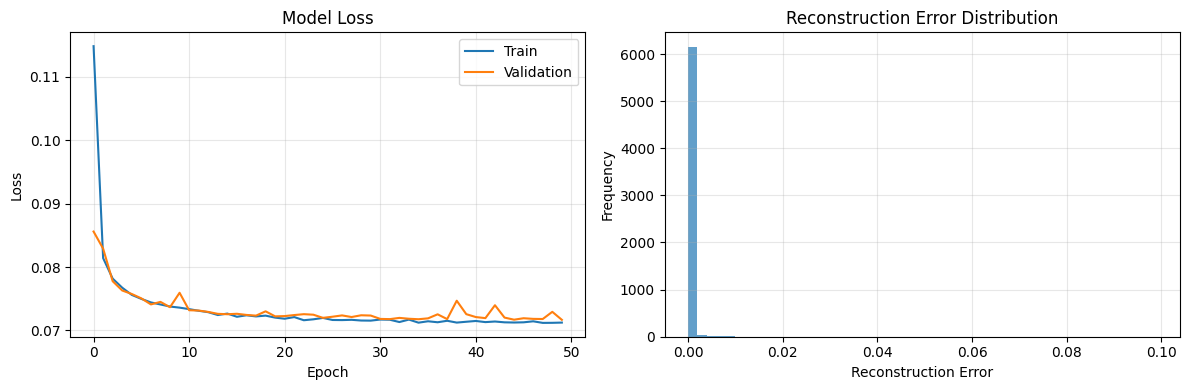

Worst reconstructed (Autoencoder):


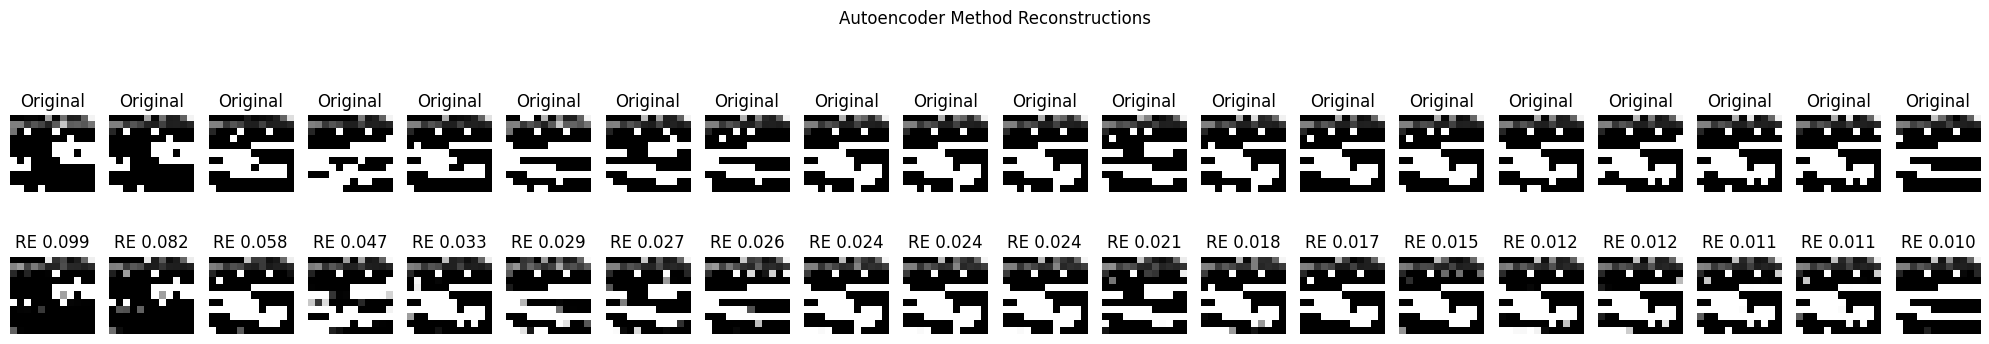

In [13]:
# Define latent space size
LATENT_SPACE_SIZE = 6

# Split data into training and testing sets
x_train, x_test = train_test_split(normal_df, test_size=0.2, random_state=42)
print(f'Training dataset shape: {x_train.shape}')
print(f'Testing dataset shape (normal): {x_test.shape}')

# Define dimensions and architecture
input_dim = x_train.shape[1]
encoding_dim = LATENT_SPACE_SIZE  # Size of the latent space

# Train the autoencoder
autoencoder, history, training_time = train_autoencoder(
    x_train, 
    x_test, 
    input_dim=input_dim, 
    latent_dim=encoding_dim, 
    epochs=50, 
    batch_size=16
)
print(f"Training time: {training_time:.2f} seconds")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True, alpha=0.3)

# Evaluate the autoencoder on test data
encoded_imgs, decoded_imgs, reconstruction_errors = evaluate_autoencoder(autoencoder, x_test)

# Plot error distribution
plt.subplot(1, 2, 2)
plt.hist(reconstruction_errors, bins=50, alpha=0.7)
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize the reconstructions
visualize_reconstructions(x_test, decoded_imgs, reconstruction_errors, "Autoencoder", make_image_from_sample)

## Testing Different TLS Datasets
Implement a function to test various TLS datasets using our trained autoencoder. This function will help us identify anomalous traffic patterns by measuring reconstruction errors.

### Dataset Testing Function

In [14]:
def test_dataset(json_files, dataset_name="Unnamed Dataset", export_results=False):
    """
    Test a TLS dataset and print detailed results.
    
    Parameters:
    -----------
    json_files : list or glob pattern
        The JSON files containing TLS records to test
    dataset_name : str
        Name of the dataset being tested (for reporting)
    export_results : bool
        Whether to export results to Excel file
    """
    # Start timing
    start_time = time.time()
    
    # Load and process data
    print(f"\n=== TESTING DATASET: {dataset_name} ===")
    raw_test_df = load_json_files(json_files)
    
    print("\nExtracting features...")
    input_test_df, top_values = extract_features_with_consistent_columns(raw_test_df, use_global=True)
    
    # Ensure the pipeline variable exists
    if 'pipeline' not in globals() or pipeline is None:
        print("Error: Pipeline is not defined")
        return {
            'dataset_name': dataset_name,
            'error': "Pipeline is not defined",
            'raw_shape': raw_test_df.shape
        }
    
    # Get the list of feature names expected by the pipeline
    expected_features = get_pipeline_feature_names(pipeline)
    if not expected_features:
        print("Error: Unable to determine the features expected by the pipeline")
        # Use globally stored feature names as a fallback
        if 'pipeline_feature_names' in globals() and pipeline_feature_names is not None:
            expected_features = pipeline_feature_names
            print(f"Using {len(expected_features)} globally stored feature names")
        else:
            print("Critical Error: Unable to recover the feature name list")
            return {
                'dataset_name': dataset_name,
                'error': "Unable to determine feature names",
                'raw_shape': raw_test_df.shape
            }
    
    # Fix column consistency issues
    fixed_df = debug_pipeline_column_issue(input_test_df, expected_features)
    

    # Transform data
    try:
        print("\nTransforming data...")
        test_df = pipeline.transform(input_test_df)
        print(f"Transformed shape: {test_df.shape}")
    except Exception as e:
        print(f"ERROR during transformation: {e}")
        
        print("\nAttempting final recovery solution...")
        
        # Create a DataFrame strictly following the pipeline's expected features
        dummy_data = np.zeros((raw_test_df.shape[0], len(expected_features)))
        fixed_df = pd.DataFrame(dummy_data, columns=expected_features)
        
        # Copy only the columns that actually exist
        for col in expected_features:
            if col in input_test_df.columns:
                fixed_df[col] = input_test_df[col].values
        
        # Retry transformation
        try:
            test_df = pipeline.transform(fixed_df)
            print(f"Emergency recovery successful! Shape: {test_df.shape}")
        except Exception as e2:
            print(f"Emergency recovery failed: {str(e2)}")
            print("Unable to process this dataset")
            
            # Return error information
            return {
                'dataset_name': dataset_name,
                'error': str(e2),
                'raw_shape': raw_test_df.shape
            }
    
    # Process with autoencoder
    encoded_test = autoencoder.encode(test_df)
    decoded_test = autoencoder.decode(encoded_test)
    
    # Calculate reconstruction errors
    test_reconstruction_errors = np.mean(np.square(test_df - decoded_test), axis=1)
    
    # Calculate statistics
    test_avg_error = np.mean(test_reconstruction_errors)
    test_median_error = np.median(test_reconstruction_errors)
    test_std_error = np.std(test_reconstruction_errors)
    test_min_error = np.min(test_reconstruction_errors)
    test_max_error = np.max(test_reconstruction_errors)
    
    # Get percentiles for better distribution understanding
    percentiles = [25, 50, 75, 90, 95, 99]
    error_percentiles = np.percentile(test_reconstruction_errors, percentiles)
    
    # Get best and worst samples
    worst10 = np.argsort(test_reconstruction_errors)[-10:][::-1]
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    
    # Visualize results
    n = 10  # Number of samples to display
    plt.figure(figsize=(20, 4))
    for i, j in enumerate(worst10):
        rec_error = test_reconstruction_errors[j]
        original = test_df[j]
        original = make_image_from_sample(original, image_pad, dim_x, dim_y)  
        reconstructed = decoded_test[j]
        reconstructed = make_image_from_sample(reconstructed, image_pad, dim_x, dim_y)
        
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original, cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f"RE {rec_error:.3f}")
        plt.axis('off')
    
    plt.suptitle(f"Worst Reconstructed Samples - {dataset_name}", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    
    # Performance summary
    print("\nPERFORMANCE SUMMARY:")
    print(f"Dataset: {dataset_name}")
    print(f"Number of samples: {raw_test_df.shape[0]}")
    print(f"Number of features: {test_df.shape[1]}")
    print(f"Average reconstruction error: {test_avg_error:.6f}")
    print(f"Processing time: {elapsed_time:.2f} seconds")
    
    # Export results if requested
    if export_results:
        # Prepare results dictionary
        results_dict = {
            'Dataset Name': dataset_name,
            'Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'Number of Samples': raw_test_df.shape[0],
            'Number of Features': test_df.shape[1],
            'Average Error': test_avg_error,
            'Median Error': test_median_error,
            'Std Deviation': test_std_error,
            'Min Error': test_min_error,
            'Max Error': test_max_error,
            'Processing Time (s)': elapsed_time
        }
        
        # Add percentiles
        for p, val in zip(percentiles, error_percentiles):
            results_dict[f'Percentile {p}'] = val
    
    return {
        'dataset_name': dataset_name,
        'avg_error': test_avg_error,
        'median_error': test_median_error,
        'std_error': test_std_error,
        'min_error': test_min_error,
        'max_error': test_max_error,
        'raw_shape': raw_test_df.shape,
        'processed_shape': test_df.shape,
        'errors': test_reconstruction_errors,
        'top_values': top_values 
    }

### Testing Multiple Datasets
Test autoencoder on various TLS traffic datasets to compare reconstruction errors.


=== TESTING DATASET: ISCX TLS Dataset ===
Loaded 1112 records from 67 files

Extracting features...
Extracting features from 1112 samples...
Using global tls.ccs list with 30 values
Using global tls.cext list with 15 values
Using global tls.csg list with 16 values
Using global tls.csv list with 0 values
Using global tls.alpn list with 5 values
Using global tls.sext list with 10 values
Using global tls.ssv list with 0 values
Combined features: (1112, 104)
Ensuring feature consistency...

=== Starting Column Consistency Debugging ===
Input DataFrame shape: (1112, 104)
Number of columns in Input DataFrame: 104
Number of columns expected by Pipeline: 104

Fixed DataFrame shape: (1112, 104)
Number of columns in Fixed DataFrame: 104
Column fix successful!

Transforming data...
Transformed shape: (1112, 130)


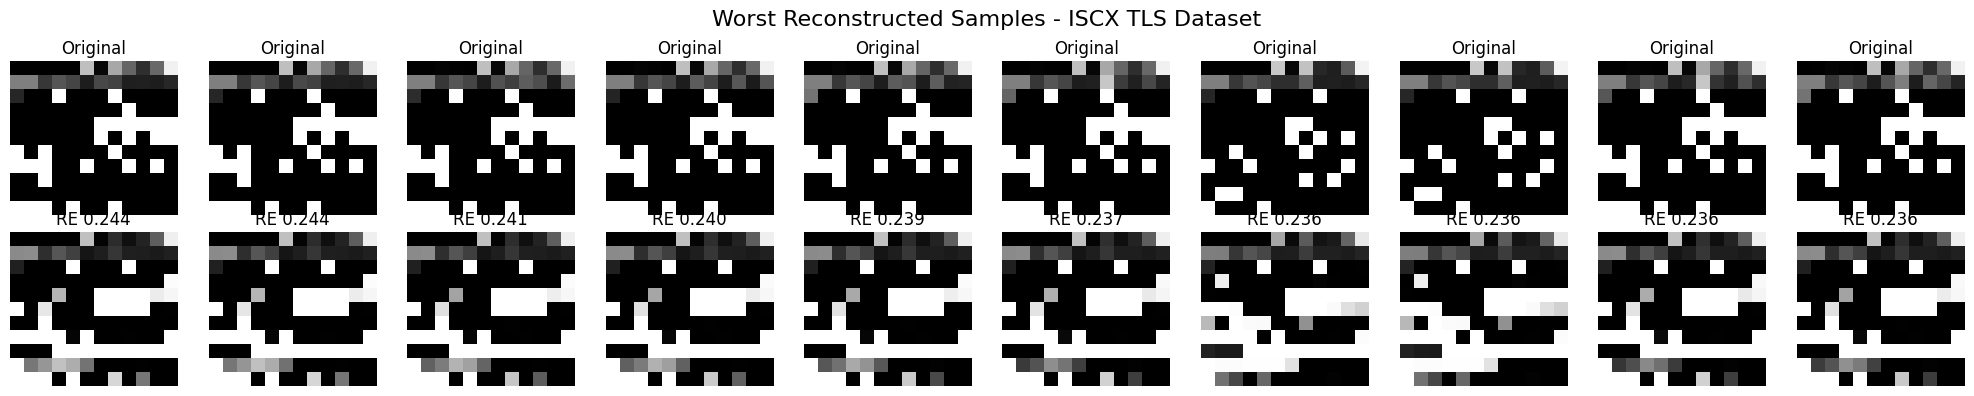


PERFORMANCE SUMMARY:
Dataset: ISCX TLS Dataset
Number of samples: 1112
Number of features: 130
Average reconstruction error: 0.099267
Processing time: 0.18 seconds

=== TESTING DATASET: Mobile TLS Dataset ===
Loaded 5616 records from 314 files

Extracting features...
Extracting features from 5616 samples...
Using global tls.ccs list with 30 values
Using global tls.cext list with 15 values
Using global tls.csg list with 16 values
Using global tls.csv list with 0 values
Using global tls.alpn list with 5 values
Using global tls.sext list with 10 values
Using global tls.ssv list with 0 values
Combined features: (5616, 104)
Ensuring feature consistency...

=== Starting Column Consistency Debugging ===
Input DataFrame shape: (5616, 104)
Number of columns in Input DataFrame: 104
Number of columns expected by Pipeline: 104

Fixed DataFrame shape: (5616, 104)
Number of columns in Fixed DataFrame: 104
Column fix successful!

Transforming data...
Transformed shape: (5616, 130)


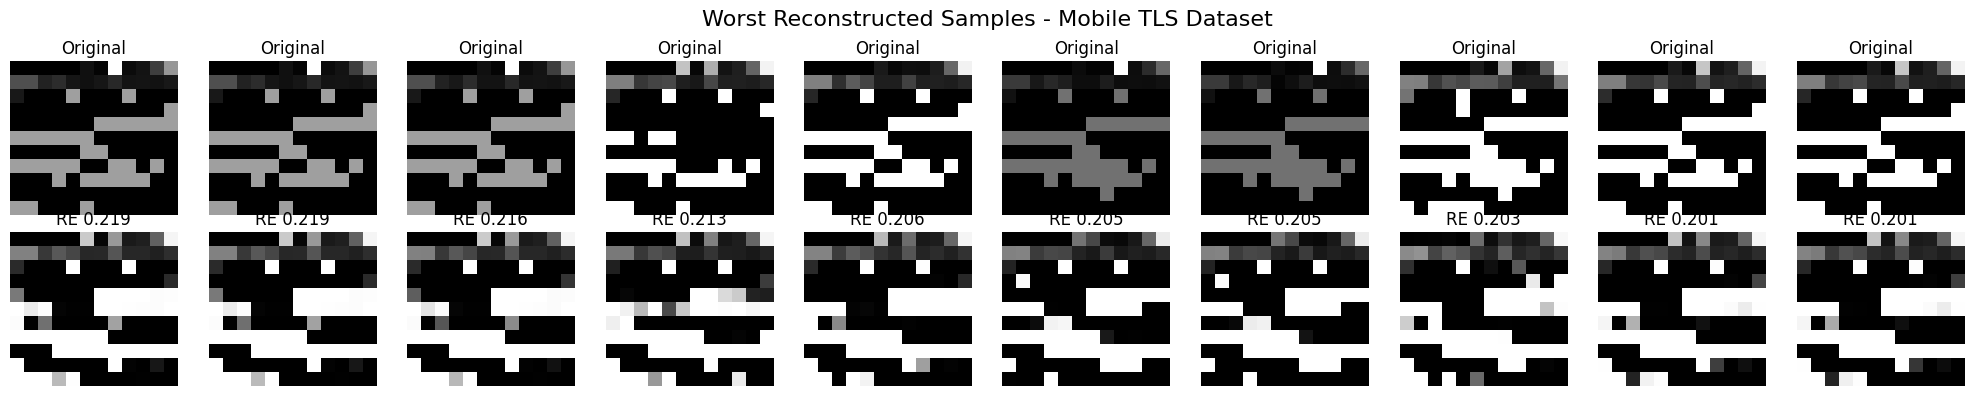


PERFORMANCE SUMMARY:
Dataset: Mobile TLS Dataset
Number of samples: 5616
Number of features: 130
Average reconstruction error: 0.123201
Processing time: 0.92 seconds

=== TESTING DATASET: Windows TLS Dataset ===
Loaded 15047 records from 43 files

Extracting features...
Extracting features from 15047 samples...
Using global tls.ccs list with 30 values
Using global tls.cext list with 15 values
Using global tls.csg list with 16 values
Using global tls.csv list with 0 values
Using global tls.alpn list with 5 values
Using global tls.sext list with 10 values
Using global tls.ssv list with 0 values
Combined features: (15047, 104)
Ensuring feature consistency...

=== Starting Column Consistency Debugging ===
Input DataFrame shape: (15047, 104)
Number of columns in Input DataFrame: 104
Number of columns expected by Pipeline: 104

Fixed DataFrame shape: (15047, 104)
Number of columns in Fixed DataFrame: 104
Column fix successful!

Transforming data...
Transformed shape: (15047, 130)


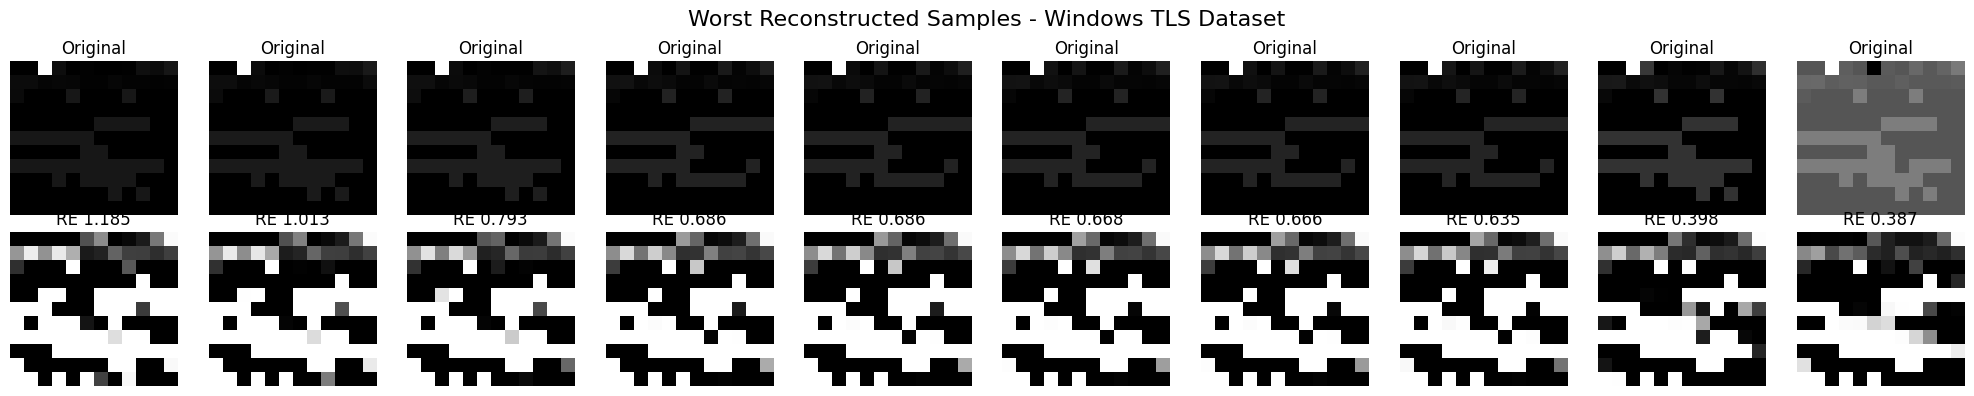


PERFORMANCE SUMMARY:
Dataset: Windows TLS Dataset
Number of samples: 15047
Number of features: 130
Average reconstruction error: 0.126844
Processing time: 1.65 seconds

=== TESTING DATASET: Desktop TLS Dataset ===
Loaded 14962 records from 1427 files

Extracting features...
Extracting features from 14962 samples...
Using global tls.ccs list with 30 values
Using global tls.cext list with 15 values
Using global tls.csg list with 16 values
Using global tls.csv list with 0 values
Using global tls.alpn list with 5 values
Using global tls.sext list with 10 values
Using global tls.ssv list with 0 values
Combined features: (14962, 104)
Ensuring feature consistency...

=== Starting Column Consistency Debugging ===
Input DataFrame shape: (14962, 104)
Number of columns in Input DataFrame: 104
Number of columns expected by Pipeline: 104

Fixed DataFrame shape: (14962, 104)
Number of columns in Fixed DataFrame: 104
Column fix successful!

Transforming data...
Transformed shape: (14962, 130)


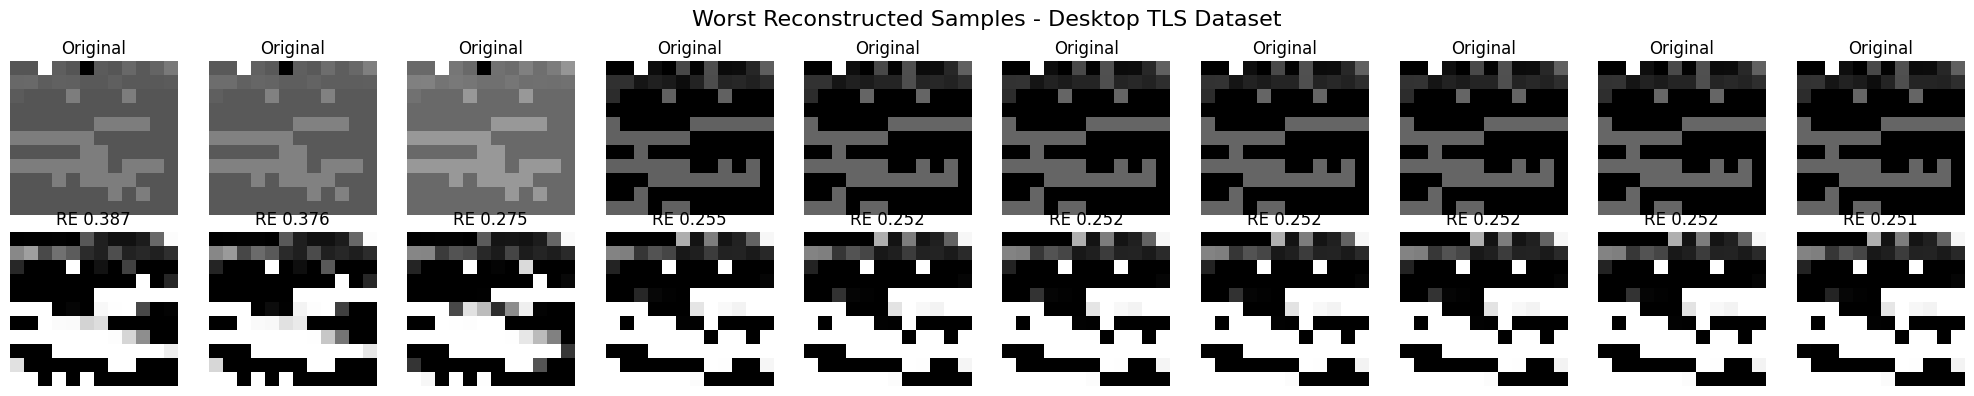


PERFORMANCE SUMMARY:
Dataset: Desktop TLS Dataset
Number of samples: 14962
Number of features: 130
Average reconstruction error: 0.126531
Processing time: 1.78 seconds

=== TESTING DATASET: CIC-AA Malware TLS Dataset ===
Loaded 462 records from 6 files

Extracting features...
Extracting features from 462 samples...
Using global tls.ccs list with 30 values
Using global tls.cext list with 15 values
Using global tls.csg list with 16 values
Using global tls.csv list with 0 values
Using global tls.alpn list with 5 values
Using global tls.sext list with 10 values
Using global tls.ssv list with 0 values
Combined features: (462, 104)
Ensuring feature consistency...

=== Starting Column Consistency Debugging ===
Input DataFrame shape: (462, 104)
Number of columns in Input DataFrame: 104
Number of columns expected by Pipeline: 104

Fixed DataFrame shape: (462, 104)
Number of columns in Fixed DataFrame: 104
Column fix successful!

Transforming data...
Transformed shape: (462, 130)


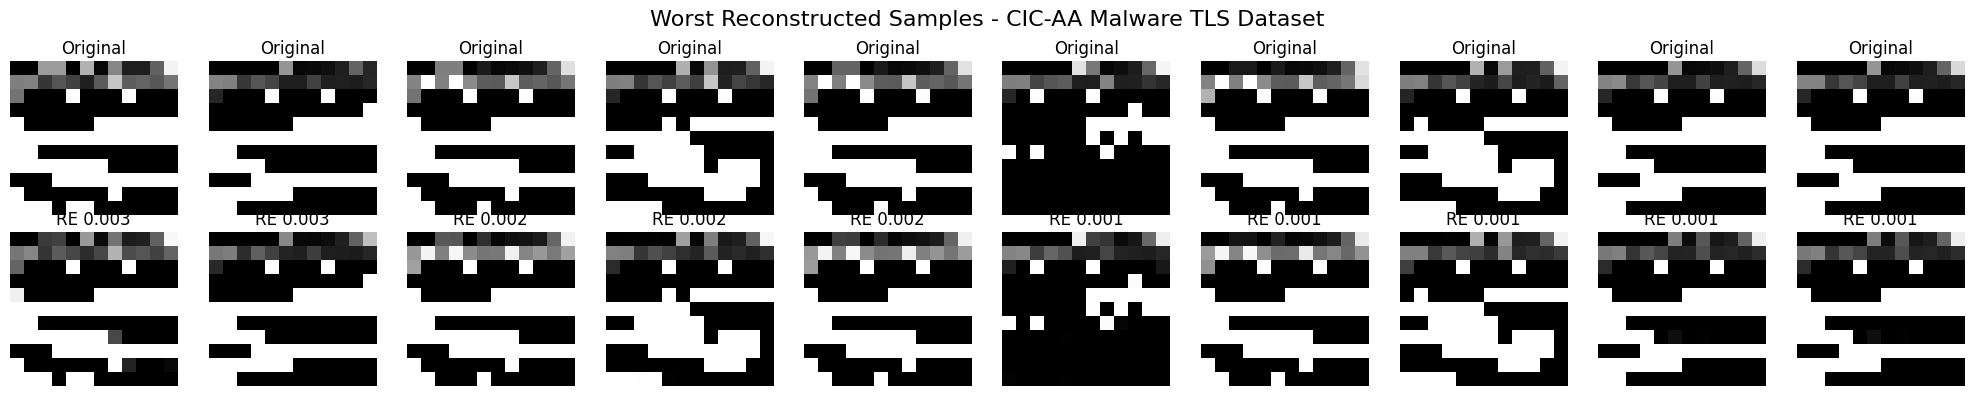


PERFORMANCE SUMMARY:
Dataset: CIC-AA Malware TLS Dataset
Number of samples: 462
Number of features: 130
Average reconstruction error: 0.000102
Processing time: 0.05 seconds

=== TESTING DATASET: CIC-AA Adware TLS Dataset ===
Loaded 7122 records from 61 files

Extracting features...
Extracting features from 7122 samples...
Using global tls.ccs list with 30 values
Using global tls.cext list with 15 values
Using global tls.csg list with 16 values
Using global tls.csv list with 0 values
Using global tls.alpn list with 5 values
Using global tls.sext list with 10 values
Using global tls.ssv list with 0 values
Combined features: (7122, 104)
Ensuring feature consistency...

=== Starting Column Consistency Debugging ===
Input DataFrame shape: (7122, 104)
Number of columns in Input DataFrame: 104
Number of columns expected by Pipeline: 104

Fixed DataFrame shape: (7122, 104)
Number of columns in Fixed DataFrame: 104
Column fix successful!

Transforming data...
Transformed shape: (7122, 130)


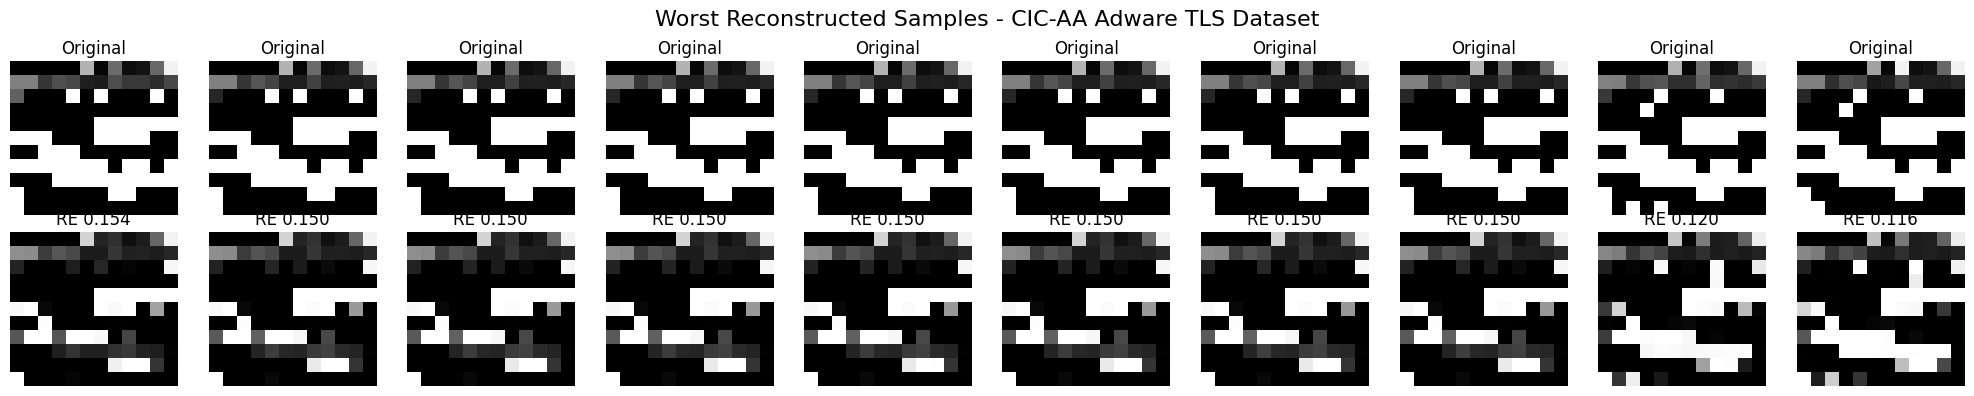


PERFORMANCE SUMMARY:
Dataset: CIC-AA Adware TLS Dataset
Number of samples: 7122
Number of features: 130
Average reconstruction error: 0.026759
Processing time: 0.78 seconds

COMPARISON OF DATASETS
                   Dataset  Samples  Features  Avg Error  Max Error  Min Error
          ISCX TLS Dataset     1112       130   0.099267   0.243736   0.000558
        Mobile TLS Dataset     5616       130   0.123201   0.218716   0.040715
       Windows TLS Dataset    15047       130   0.126844   1.184945   0.025943
       Desktop TLS Dataset    14962       130   0.126531   0.386812   0.025943
CIC-AA Malware TLS Dataset      462       130   0.000102   0.003323   0.000010
 CIC-AA Adware TLS Dataset     7122       130   0.026759   0.154376   0.000010


In [15]:
# Store results in a dictionary
results = {}

# Test ISCX dataset
results['iscx'] = test_dataset(
    json_files=glob.glob("../datasets/iscx.tls/*.json"),
    dataset_name="ISCX TLS Dataset",
    export_results=True
)

# Test Mobile dataset
results['mobile'] = test_dataset(
    glob.glob("../datasets/mobile.tls/*.json"),
    dataset_name="Mobile TLS Dataset",
    export_results=True
)

# Test Windows dataset
results['windows'] = test_dataset(
    glob.glob("../datasets/windows.tls/*.json"),
    dataset_name="Windows TLS Dataset",
    export_results=True
)

# Test Desktop datasets
results['desktop'] = test_dataset(
    glob.glob("../datasets/desktop.tls/*.json"),
    dataset_name="Desktop TLS Dataset",
    export_results=True
)

# # Test cic-aa.normal datasets
# results['cic-aa.normal'] = test_dataset(
#     glob.glob("../datasets/cic-aa.normal.tls/*.json"),
#     dataset_name="CIC-AA Normal TLS Dataset",
#     export_results=True
# )

# Test cic-aa.malware datasets
results['cic-aa.malware'] = test_dataset(
    glob.glob("../datasets/cic-aa.malware.tls/*.json"),
    dataset_name="CIC-AA Malware TLS Dataset",
    export_results=True
)

# Test cic-aa.adware datasets
results['cic-aa.adware'] = test_dataset(
    glob.glob("../datasets/cic-aa.adware.tls/*.json"),
    dataset_name="CIC-AA Adware TLS Dataset",
    export_results=True
)

# Compare datasets
print("\n" + "="*80)
print("COMPARISON OF DATASETS")
print("="*80)

comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Dataset': result['dataset_name'],
        'Samples': result['raw_shape'][0],
        'Features': result['processed_shape'][1],
        'Avg Error': result['avg_error'],
        'Max Error': result['max_error'],
        'Min Error': result['min_error']
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

## Reconstruction

In this section, threshold tuning was performed to optimize the anomaly detection process. Metrics such as recall, precision, and accuracy were observed across different threshold values to identify the optimal threshold for anomaly classification. The recall metric was particularly emphasized to ensure the detection of as many anomalies as possible.

For further details and reference, the implementation was inspired by the following repository:  
[Anomaly Detection with Autoencoders](https://github.com/AarnoStormborn/anomaly-detection-with-autoencoder/blob/main/anomaly-detection-with-autoencoders.ipynb)


In [16]:
# Define constants for dataset labels
NORMAL_LABEL = 'Normal dataset (Normal.tls)'
MALICIOUS_LABEL = 'Malicious dataset (Adware.tls)'

# load the malicious dataset
abnormal_raw_df = load_json_files(glob.glob("../datasets/cic-aa.adware.tls/*.json"))
# abnormal_raw_df = load_json_files(glob.glob("../datasets/cic-aa.malware.tls/*.json"))
# abnormal_raw_df = load_json_files(glob.glob("../datasets/iscx.tls/*.json"))

input_abnormal_df, _ = extract_features_with_consistent_columns(abnormal_raw_df, use_global=True)
    
abnormal_df = pipeline.transform(input_abnormal_df)

# calculate reconstruction errors for abnormal data
encoded_abnormal = autoencoder.encode(abnormal_df)
decoded_abnormal = autoencoder.decode(encoded_abnormal)
errors_abnormal = np.mean(np.square(abnormal_df - decoded_abnormal), axis=1)

# create a DataFrame for the reconstruction errors
recons_abnormal_df = pd.DataFrame({
    'error': errors_abnormal,
    'y_true': [MALICIOUS_LABEL] * len(errors_abnormal)
})

# let normal_df be the normal data
recons_normal_df = pd.DataFrame({
    'error': reconstruction_errors,
    'y_true': [NORMAL_LABEL] * len(reconstruction_errors)
})

recons_df = pd.concat([recons_normal_df, recons_abnormal_df], ignore_index=True)
recons_df.head()

Loaded 7122 records from 61 files
Extracting features from 7122 samples...
Using global tls.ccs list with 30 values
Using global tls.cext list with 15 values
Using global tls.csg list with 16 values
Using global tls.csv list with 0 values
Using global tls.alpn list with 5 values
Using global tls.sext list with 10 values
Using global tls.ssv list with 0 values
Combined features: (7122, 104)
Ensuring feature consistency...


,error,y_true
0,0.000017,Normal dataset (Normal.tls)
1,0.000042,Normal dataset (Normal.tls)
2,0.000022,Normal dataset (Normal.tls)
3,0.000016,Normal dataset (Normal.tls)
4,0.000023,Normal dataset (Normal.tls)


In [17]:
def thresholdTuning(df, iterations):
    # Create a mapping of string labels to numeric values for classification metrics
    label_mapping = {
        NORMAL_LABEL: 0,
        MALICIOUS_LABEL: 1
    }

    # Convert string labels to numeric for classification report
    y_true_numeric = df['y_true'].map(label_mapping)

    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }

    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = (df['error'] > thresh_value).astype(int)  # Convert boolean to int
        cr = classification_report(y_true_numeric, preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']

        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)

        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")

    return pd.DataFrame(thresh_df)

# Run threshold tuning with 100 iterations
thresh_df = thresholdTuning(recons_df, 100)

# Select the threshold with maximum recall
threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold: 0.0000	Accuracy: 0.533		Precision: 0.767	Recall Score: 0.500
Threshold: 0.0000	Accuracy: 0.543		Precision: 0.769	Recall Score: 0.511
Threshold: 0.0000	Accuracy: 0.553		Precision: 0.772	Recall Score: 0.521
Threshold: 0.0000	Accuracy: 0.563		Precision: 0.775	Recall Score: 0.532
Threshold: 0.0000	Accuracy: 0.575		Precision: 0.778	Recall Score: 0.544
Threshold: 0.0000	Accuracy: 0.583		Precision: 0.778	Recall Score: 0.553
Threshold: 0.0000	Accuracy: 0.593		Precision: 0.781	Recall Score: 0.564
Threshold: 0.0000	Accuracy: 0.602		Precision: 0.784	Recall Score: 0.574
Threshold: 0.0000	Accuracy: 0.612		Precision: 0.787	Recall Score: 0.585
Threshold: 0.0000	Accuracy: 0.616		Precision: 0.772	Recall Score: 0.590
Threshold: 0.0000	Accuracy: 0.606		Precision: 0.722	Recall Score: 0.580
Threshold: 0.0000	Accuracy: 0.605		Precision: 0.701	Recall Score: 0.579
Threshold: 0.0000	Accuracy: 0.606		Precision: 0.691	Recall Score: 0.581
Threshold: 0.0000	Accuracy: 0.596		Precision: 0.659	Recall Score

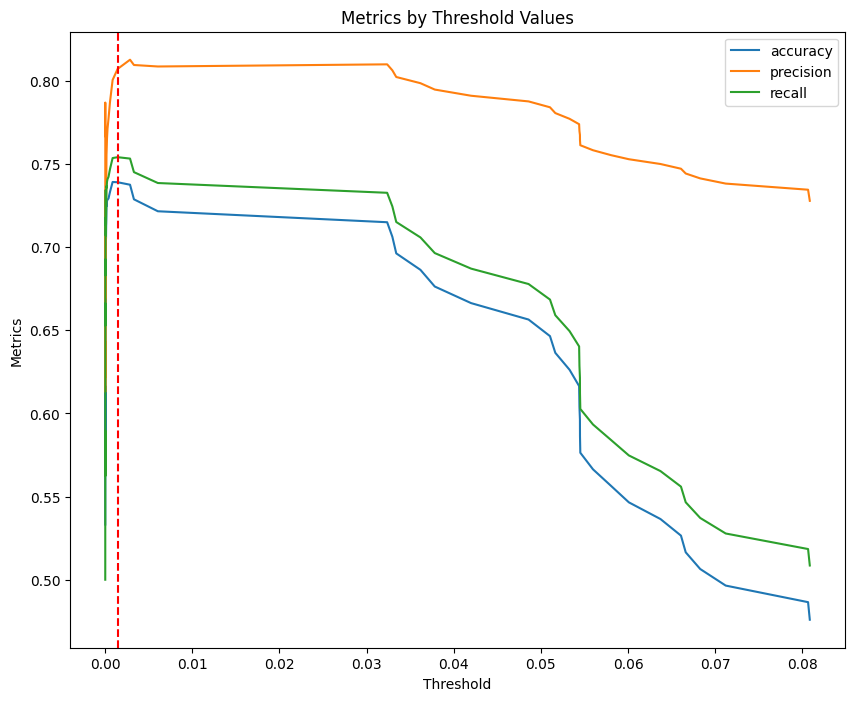

In [18]:
# Plot metrics by threshold values
plt.figure(figsize=(10,8))
plt.plot(thresh_df['threshold'], thresh_df['accuracy'], label='accuracy')
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='precision')
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

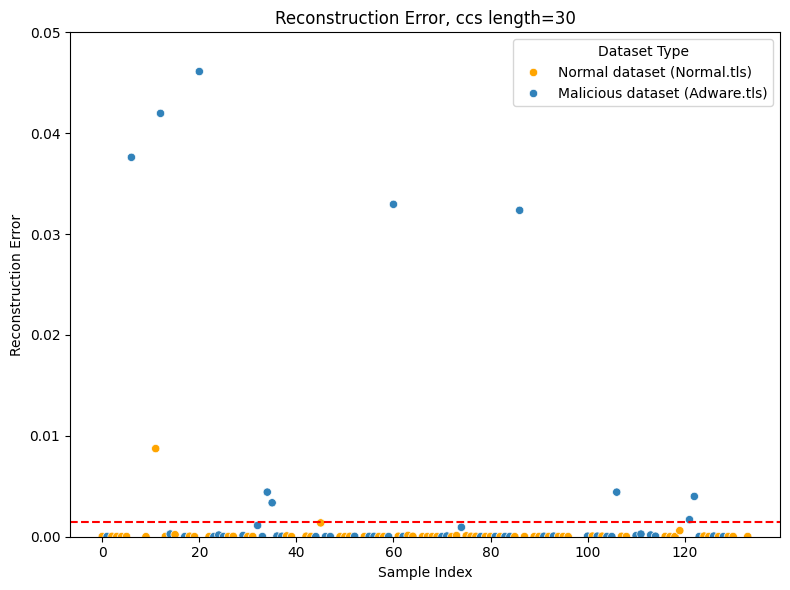

In [19]:
# Visualize reconstruction errors with the selected threshold
temp = recons_df.sample(frac=0.01, random_state=42).reset_index(drop=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true', palette=['orange', '#3182ba'])
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.ylim(0, 0.05)  
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title(f'Reconstruction Error, ccs length={TOP_N_CCS}')
plt.legend(title='Dataset Type')
plt.tight_layout()
plt.show()